# Spectral Clustering Notebook

## Table of Contents

1. [Introduction & Definition](#1-introduction--definition)
2. [How It Works - Math & Intuition](#2-how-it-works---math--intuition)
3. [When To Use Spectral Clustering](#3-when-to-use-spectral-clustering)
4. [Pros & Cons](#4-pros--cons)
5. [Wine Dataset](#5-wine-dataset)
6. [Exploratory Data Analysis (EDA)](#6-exploratory-data-analysis)
    - 6.1 Import Libraries
    - 6.2 Load Dataset
    - 6.3 Dataset Overview
    - 6.4 Missing Values & Duplicates
    - 6.5 Summary Statistics
    - 6.6 Feature Distributions
    - 6.7 PCA Projection
    - 6.8 Correlation Heatmap
7. [Data Cleaning](#7-data-cleaning)
8. [Train / Validation / Test Split](#8-train--validation--test-split)
9. [Model Training](#9-model-training)
10. [Validation](#10-validation)
11. [Final Test Set Evaluation](#11-final-test-set-evaluation)
12. [Conclusion](#12-conclusion)


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, make_blobs, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.neighbors import KNeighborsClassifier, kneighbors_graph
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from scipy.sparse.csgraph import laplacian as csgraph_laplacian

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

sns.set_palette("Set2")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready")


Environment ready


## 1. Introduction & Definition

**Spectral Clustering** is an unsupervised machine learning algorithm used to group similar data points into clusters.

Unlike **K-Means**, which works best when clusters are roughly round or centered around a point, Spectral Clustering can find **more complex shapes**, such as crescents, spirals, and rings.

### How It Works — Simple Idea

Instead of looking at the data as just points, Spectral Clustering treats the data as a **graph**:

- Each data point becomes a **node**.
- Points that are close or very similar are **connected**.
- Strong connections mean that two points are very similar.
- Weak or missing connections mean that two points are less similar.

The algorithm then analyzes this graph to find groups of strongly connected points.

Technically, it uses the **eigenvalues and eigenvectors of a graph Laplacian matrix** to transform the data into a new representation where the clusters are easier to separate.

Finally, **K-Means is applied to this new representation** to produce the final clusters.

### The Main Idea

A simple way to remember it is:

**K-Means:** "Which center is this point closest to?"

**Spectral Clustering:** "Which group of strongly connected points does this point belong to?"

This is why Spectral Clustering can discover cluster shapes that K-Means may struggle with.

## 2. How It Works — Math & Intuition

Spectral Clustering works by turning the dataset into a **graph**.

Imagine that:

- Each data point is a **node**.
- Similar or nearby points are **connected**.
- A stronger connection means the points are more similar.

These connections are stored in a **similarity matrix** `W`.

### From the Graph to Clusters

Spectral Clustering then builds a **graph Laplacian** from this similarity matrix:

$$
L = D - W
$$

where `D` is the **degree matrix**. It tells us how strongly each point is connected to all the other points.

The algorithm then calculates the **eigenvectors** of this matrix. These eigenvectors transform the original data into a new space where the clusters are easier to separate.

Finally, **K-Means is applied to this new representation** to create the final clusters.

### The Process

The whole process can be simplified into 5 steps:

1. **Build a similarity graph**  
   Connect points that are similar or close to each other.

2. **Build the graph Laplacian**  
   This captures how all the points are connected.

3. **Find the important eigenvectors**  
   The eigenvectors reveal the main structure of the graph.

4. **Create a new representation**  
   Each data point gets new coordinates based on these eigenvectors.

5. **Run K-Means**  
   K-Means groups the points in this new space, where the clusters are easier to separate.

### Why Does This Help?

Imagine two crescent-shaped clusters. In the original space, they may be difficult for K-Means to separate because they are not round.

Spectral Clustering looks at **which points are connected to each other**. Points along the same crescent are strongly connected, even if they are far from the center of that crescent.

After transforming the data, the two crescents become easier to separate, and K-Means can then find them.

### Key Terms

- **`W` — Similarity Matrix:** Shows how similar or connected each pair of points is.
- **`D` — Degree Matrix:** Shows how strongly each point is connected overall.
- **`L` — Graph Laplacian:** Represents the structure of the entire graph.
- **`k` — Number of clusters:** The number of groups we want to find.
- **Eigenvectors:** Help transform the data into a new space where the clusters are easier to separate.

### Main Idea

The easiest way to remember Spectral Clustering is:

**Build connections → understand the graph → transform the data → apply K-Means.**

So Spectral Clustering does not replace K-Means completely. Instead, it **changes the representation of the data first**, making difficult-shaped clusters easier for K-Means to separate.

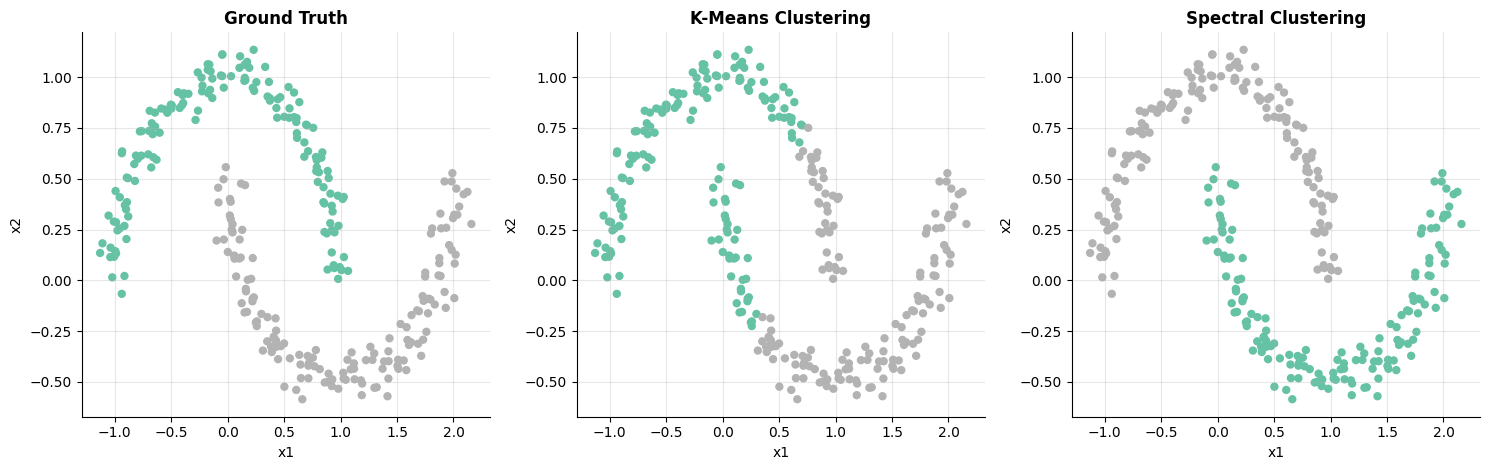

K-Means   ARI vs ground truth: 0.247
Spectral  ARI vs ground truth: 1.000


In [2]:
# Demonstrate why Spectral Clustering succeeds where K-Means fails: two interleaving crescents
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)

kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans_moons.fit_predict(X_moons)

spectral_moons = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=RANDOM_STATE,
)
spectral_labels = spectral_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_true, cmap="Set2", s=25)
axes[0].set_title("Ground Truth", fontweight="bold")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_labels, cmap="Set2", s=25)
axes[1].set_title("K-Means Clustering", fontweight="bold")

axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=spectral_labels, cmap="Set2", s=25)
axes[2].set_title("Spectral Clustering", fontweight="bold")

for ax in axes:
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

print(f"K-Means   ARI vs ground truth: {adjusted_rand_score(y_moons_true, kmeans_labels):.3f}")
print(f"Spectral  ARI vs ground truth: {adjusted_rand_score(y_moons_true, spectral_labels):.3f}")


### What This Plot Shows

This example shows why **Spectral Clustering can work better than K-Means for complex-shaped clusters**.

We use a dataset containing **two interleaving crescent-shaped groups**.

- **Ground Truth:** Shows the two actual crescent clusters.
- **K-Means:** Tries to separate the points based on their distance to two center points. Because the crescents are curved, K-Means cannot follow their shape and mixes points from the two groups.
- **Spectral Clustering:** Looks at the **connections between nearby points**. Points that are close to each other along the same crescent remain connected, allowing the algorithm to follow the curved shape.

### ARI Score

We use the **Adjusted Rand Index (ARI)** to compare the predicted clusters with the known ground truth.

The ARI ranges from **-1 to 1**:

- **1:** Perfect match with the true clusters.
- **Around 0:** The clustering is similar to random grouping.
- **Below 0:** Worse than random agreement.

Our results are:

- **K-Means:** `0.247` → poor separation of the two moons.
- **Spectral Clustering:** `1.000` → perfect recovery of the two clusters.

### Main Idea

**K-Means looks for groups around centers.**

**Spectral Clustering looks at how points are connected.**

This is why Spectral Clustering is especially useful for **non-convex or irregularly shaped clusters**, such as crescents, spirals, and rings.

## 3. When to Use Spectral Clustering

Spectral Clustering is a good choice when the data contains **complex or irregularly shaped clusters**.

### When It Works Well

Use Spectral Clustering when:

- Clusters are **curved or non-convex**, such as crescents or spirals.
- Clusters are **elongated or ring-shaped**.
- K-Means struggles because the groups are not round.
- The important information comes from **how points are connected to their neighbors**.

In these situations, the graph-based approach of Spectral Clustering can capture relationships that simple distance-to-centroid methods may miss.

### When It Is Not Ideal

Spectral Clustering can become expensive for **very large datasets**.

Building the similarity graph and calculating the eigenvectors can require a lot of computation as the number of data points increases.

One way to make it more practical is to use a **k-nearest-neighbor graph**, where each point is connected only to its closest neighbors instead of every other point.

Another limitation is that Spectral Clustering needs us to choose the **number of clusters (`k`) beforehand**, similar to K-Means.

## 4. Pros & Cons

Spectral Clustering is useful because it can find **complex cluster shapes** that methods like K-Means may miss.

### Advantages

- **Handles complex shapes:** It can find crescents, spirals, rings, and other irregular clusters.
- **Focuses on connectivity:** It looks at how points are connected to each other instead of only looking at their distance from a center.
- **Flexible:** It can be applied to many types of problems, such as image segmentation, social networks, and biological data.
- **Works well with K-Means:** After transforming the data, it uses K-Means in the new space, making the final clustering simple.

### Disadvantages

- **Can be computationally expensive:** Building the similarity graph and calculating eigenvectors becomes difficult for very large datasets.
- **Sensitive to parameters:** The results can change depending on how we build the similarity graph and the parameters we choose, such as the number of neighbors.
- **Requires `k`:** We need to choose the number of clusters before running the algorithm, just like K-Means.
- **No direct prediction for new points:** Standard Spectral Clustering is **transductive**, meaning it clusters the data points used to build the graph. It does not naturally provide a `.predict()` method for a completely new point.

## 5. Wine Dataset

For the practical part of this notebook, we will use the **Wine dataset** from scikit-learn.

The dataset contains chemical measurements from **178 wines** produced from **3 different grape varieties (cultivars)**.

Each wine has **13 chemical features**, including:

- Alcohol
- Malic acid
- Flavanoids
- Color intensity
- Proline
- And other chemical measurements

The dataset also contains the real cultivar labels (`0`, `1`, and `2`). However, we will **not use these labels when training the clustering model**.

Instead, we will let Spectral Clustering look only at the chemical features and discover the groups on its own.

### Why Keep the True Labels?

We keep the real labels separately so that, after clustering, we can compare our results with the actual grape varieties.

This allows us to answer an important question:

> **Can Spectral Clustering discover the real wine groups using only their chemical properties?**

This is how unsupervised learning can be useful in real-world situations. We may have lots of measurements but **no labels**, so clustering can help us discover natural groups before we know what those groups represent.

## 6. Exploratory Data Analysis



### 6.1 Import Libraries



In [4]:
# All libraries needed for EDA are already imported in the setup cell above.
print("Libraries ready for EDA")


Libraries ready for EDA


### 6.2 Load Dataset



In [5]:
# Load the Wine dataset from scikit-learn
wine_bunch = load_wine()

df = pd.DataFrame(wine_bunch.data, columns=wine_bunch.feature_names)
df["target"] = wine_bunch.target  # true cultivar label: 0, 1, or 2 (kept aside, not used for fitting)

target_names = dict(enumerate(wine_bunch.target_names))
print("Loaded dataset from sklearn.datasets.load_wine()")
print("Dataset shape:", df.shape)
print("Cultivars:", target_names)


Loaded dataset from sklearn.datasets.load_wine()
Dataset shape: (178, 14)
Cultivars: {0: np.str_('class_0'), 1: np.str_('class_1'), 2: np.str_('class_2')}


In [6]:
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

### Understanding the Dataset

The dataset contains:

- **178 wines**
- **13 chemical features**
- **1 target column** representing the actual wine cultivar

There are **no missing values**, and all 13 chemical features are already numeric, so we do not need to perform any categorical encoding.

The `target` column contains the real cultivar labels. However, we will **not use it when training Spectral Clustering**. We will keep it aside only for evaluating the final clustering results.

### 6.4 Missing Values & Duplicates



In [8]:
print("Missing values per column:\n", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
 0
Duplicate rows: 0


In [9]:
df.drop(columns="target").describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


**What to look for:** Compare the `min`, `max`, and `mean` rows across columns. `proline` ranges up intothe hundreds/thousands, while features like `hue` or `nonflavanoid_phenols` live in a range below 1. This scalemismatch is *critical* for Spectral Clustering: since the similarity graph is built from distances between points,a feature with a naturally larger numeric range would completely dominate the similarity calculation unless westandardize first — a large-scale feature like `proline` could single-handedly decide which points look "close"to each other, drowning out the signal from every other feature.

### 6.6 Feature Distributions



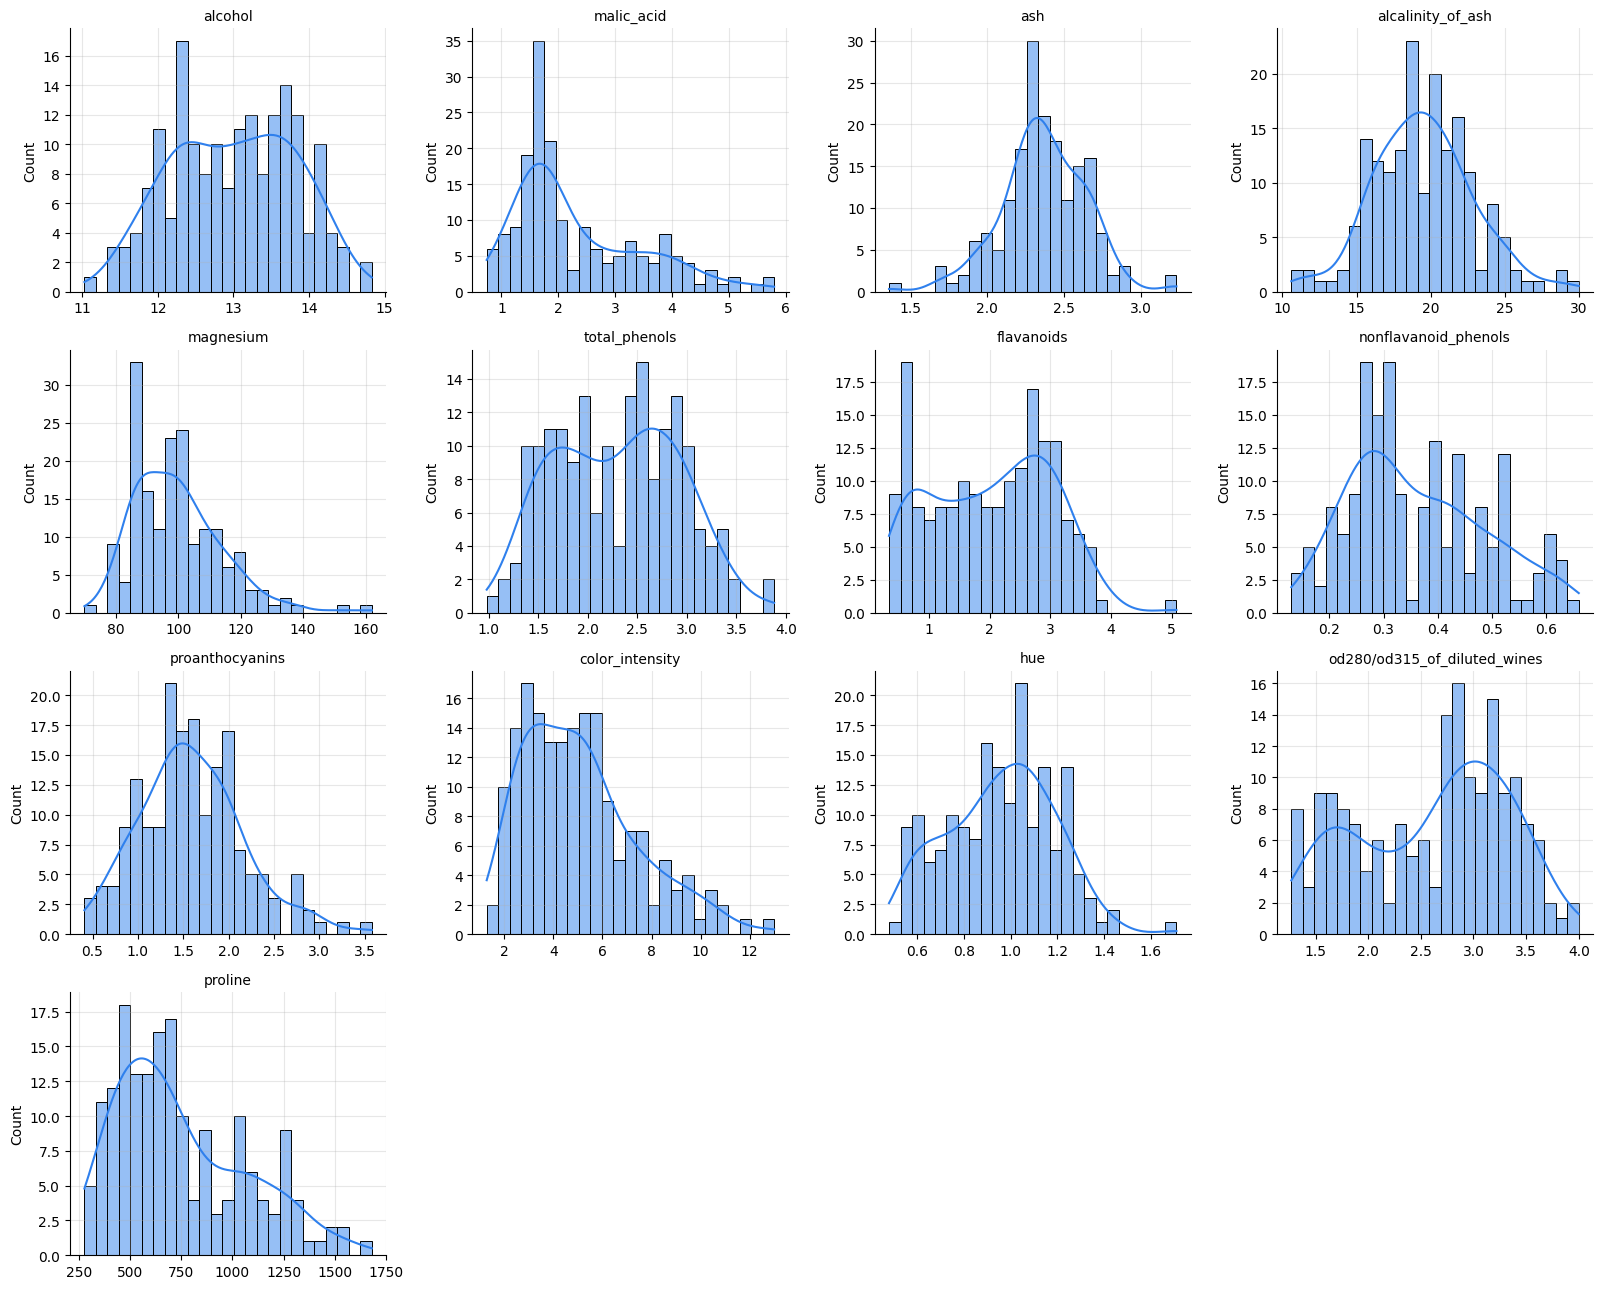

In [10]:
feature_cols = [c for c in df.columns if c != "target"]

fig, axes = plt.subplots(4, 4, figsize=(16, 13))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], bins=25, kde=True, ax=axes[i], color="#2f80ed")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")

for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### What These Distributions Show

These histograms show how each of the **13 chemical features** is distributed across the 178 wines.

Some features, such as **flavanoids, color intensity, proline, and OD280/OD315**, show multiple peaks or groups in their distributions.

This is interesting because multiple peaks can suggest that the wines are made up of **different sub-groups** with different chemical characteristics.

Other features, such as `ash` and `magnesium`, look more like one smooth distribution, so they may be less useful on their own for separating the wine groups.

### Why Does This Matter?

We are looking for evidence that the wines contain **natural groups based on their chemical properties**.

If several features show different patterns or multiple groups, this suggests that Spectral Clustering may be able to use these chemical differences to discover the underlying wine groups.

**Important:** We are only exploring the features here. The `target` labels are still not used.

### 6.7 PCA Projection (Preview of Cluster Structure)



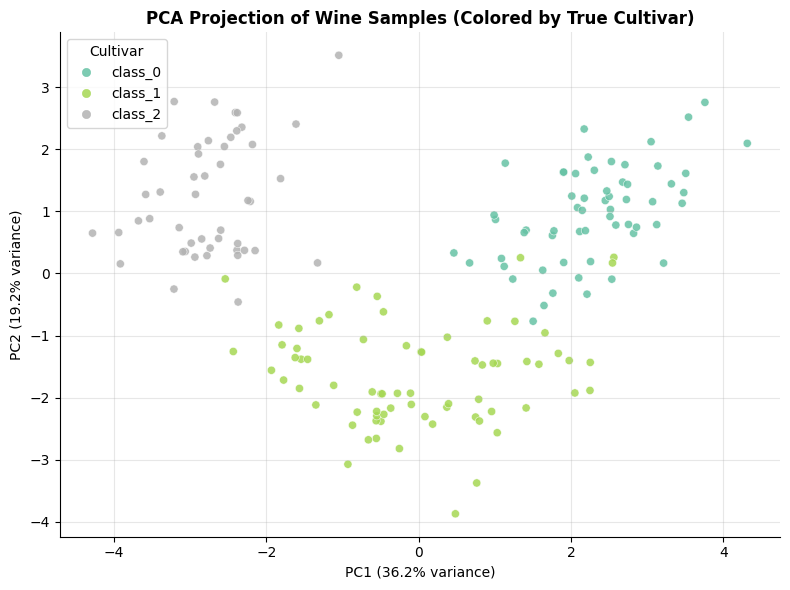

In [11]:
# 13-dimensional data can't be scatter-plotted directly, so we use PCA purely as a
# 2D *visualization* tool here (it is NOT used anywhere in the actual clustering pipeline).
# We standardize first so PCA isn't dominated by large-scale features like `proline`.
X_all = df[feature_cols].values
y_all_true = df["target"].values

scaler_preview = StandardScaler()
X_all_scaled_preview = scaler_preview.fit_transform(X_all)

pca_preview = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_preview = pca_preview.fit_transform(X_all_scaled_preview)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_preview[:, 0], X_pca_preview[:, 1],
    c=y_all_true, cmap="Set2", s=35, alpha=0.85, edgecolor="white", linewidth=0.4
)
plt.title("PCA Projection of Wine Samples (Colored by True Cultivar)", fontweight="bold")
plt.xlabel(f"PC1 ({pca_preview.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_preview.explained_variance_ratio_[1]*100:.1f}% variance)")
handles, _ = scatter.legend_elements()
plt.legend(handles, wine_bunch.target_names, title="Cultivar")
plt.tight_layout()
plt.show()


### What This PCA Plot Shows

The Wine dataset has **13 features**, so we cannot easily visualize all of them at once.

We use **PCA only to create a 2D visualization**. PCA reduces the 13 features to 2 new dimensions while keeping as much information as possible.

The colors show the **real wine cultivars**. Remember: these labels are used only for visualization here, **not for training Spectral Clustering**.

### What We Can See

The three wine groups appear to form **fairly separate groups**, with only some overlap between them.

This is a good sign because it tells us that the chemical features contain enough information to distinguish the different wine types.

### Why Do We Do This?

This gives us a visual idea of what we hope Spectral Clustering will discover later.

We will still run Spectral Clustering on the **full 13-dimensional dataset**, not on these two PCA components.

**In short:**

**13 chemical features → PCA for visualization → see that natural groups appear to exist → use Spectral Clustering on all 13 features.**

### 6.8 Correlation Heatmap



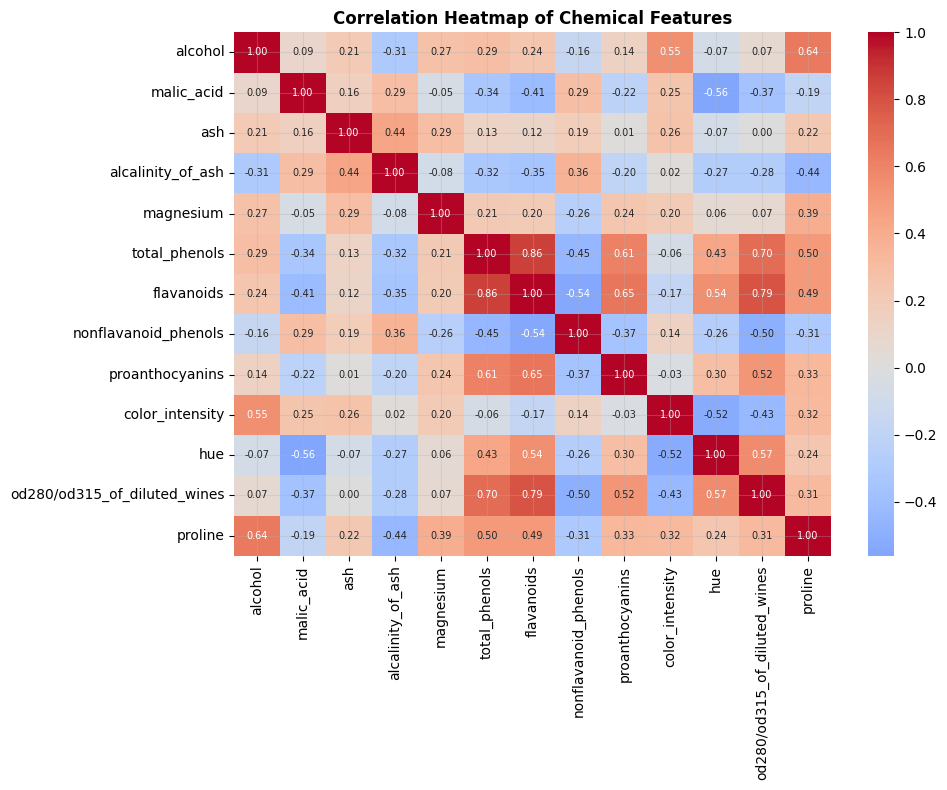

In [12]:
plt.figure(figsize=(10, 8))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation Heatmap of Chemical Features", fontweight="bold")
plt.tight_layout()
plt.show()


### What This Correlation Heatmap Shows

The heatmap shows how strongly the **13 chemical features** are related to each other.

We can see that some features are strongly correlated. For example:

- `flavanoids` is strongly related to `total_phenols`.
- `flavanoids` is also related to `od280/od315_of_diluted_wines`.
- `color_intensity` and `hue` are also related.

This means that some chemical measurements contain **similar or overlapping information**.

### Why Does This Matter?

We do not need to remove these features. Instead, we will **standardize all the features** so that no feature dominates the similarity calculations simply because it has a larger numerical scale.

This allows Spectral Clustering to consider **all 13 chemical features fairly** when measuring similarity between wines.

**Main idea:** Some features are related, but we keep them and use standardization to prepare the data for clustering.

## 7. Data Cleaning



In [13]:
# No duplicate rows and no missing values were found, so there is nothing to drop here.
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows (none found)")


Removed 0 duplicate rows (none found)


## 8. Train / Validation / Test Split

Before running Spectral Clustering, we divide the wines into three groups:

- **Training set:** 106 wines (60%)
- **Validation set:** 36 wines (20%)
- **Test set:** 36 wines (20%)

### Why Do We Split the Data?

Normally, clustering does not need a train/test split because it is unsupervised. However, Spectral Clustering has an important limitation: it is **transductive**.

This means it learns a graph from the specific data it receives and does not have a built-in way to assign a completely new wine to an existing cluster.

To solve this, we use a **K-Nearest Neighbors (K-NN) classifier** after clustering:

1. Run Spectral Clustering on the **training data**.
2. Give each training wine its discovered cluster label.
3. Train K-NN to learn how to assign new wines to those clusters.
4. Use K-NN to assign clusters to the **validation and test wines**.

This gives us a practical way to evaluate how well the discovered clusters work on new data.

### What About the Real Cultivar Labels?

The `target` column contains the real wine cultivar, but we keep it completely separate from the clustering process.

We use these labels **only after clustering** to evaluate how well our discovered groups match the real wine varieties.

### Why Three Sets?

- **Training:** Build the clustering structure.
- **Validation:** Choose the best settings, such as the number of clusters `k`.
- **Test:** Perform the final evaluation on data that was never used to make decisions.

This prevents us from choosing a model based on the test data and gives us a more honest measure of how well Spectral Clustering generalizes to **new wines**.

In [14]:
# Ensure RANDOM_STATE exists even if the setup cell was not run
if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

X = df[feature_cols].values
y_true = df["target"].values  # held aside: used ONLY for evaluation, never for fitting

# Split into training+validation and test sets (80% / 20%)
X_temp, X_test, y_temp_true, y_test_true = train_test_split(
    X, y_true, test_size=0.2, random_state=RANDOM_STATE, stratify=y_true
)

# Split the 80% temporary set into training and validation (75% / 25% of it -> 60% / 20% overall)
X_train, X_val, y_train_true, y_val_true = train_test_split(
    X_temp, y_temp_true, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp_true
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (106, 13)
Validation shape: (36, 13)
Test shape: (36, 13)


### Training the Model: Choosing the Right Number of Clusters

The most important choice in Spectral Clustering is **`k`**, which represents the number of clusters we want to find.

We do not simply assume that `k = 3` because we know the Wine dataset has three real cultivars. Instead, we test different values of `k` and see which one works best.

We use two main metrics:

- **Silhouette Score:** Measures how well separated the clusters are. Higher is better.
- **Adjusted Rand Index (ARI):** Compares the discovered clusters with the real cultivar labels. A score close to `1` means strong agreement.

The real labels are **not used to train the clustering model**. They are only used afterward to evaluate how well the discovered groups match the actual wine varieties.

### Validation: Choosing the Best Settings

We use the **validation set** to compare different values of `k` and different similarity-graph settings.

The **test set is kept completely separate** and is not used to make any decisions.

Once we choose the best settings using the training and validation data, we evaluate the final model on the test set.

This gives us a fair answer to the question:

> **Can the clustering structure discovered from the training wines also work well on completely unseen wines?**

## 9. Model Training



In [15]:
# Baseline: plain K-Means (does not require an out-of-sample extension -- it has a native .predict)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

baseline_kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
baseline_kmeans.fit(X_train_scaled)

baseline_val_pred = baseline_kmeans.predict(X_val_scaled)
baseline_val_ari = adjusted_rand_score(y_val_true, baseline_val_pred)
baseline_val_sil = silhouette_score(X_val_scaled, baseline_val_pred)

print(f"Baseline K-Means (k=3) -- Validation ARI: {baseline_val_ari:.3f} | Silhouette: {baseline_val_sil:.3f}")


Baseline K-Means (k=3) -- Validation ARI: 1.000 | Silhouette: 0.264


### K-Means Baseline

We first use **K-Means with `k=3`** as a baseline to compare with Spectral Clustering.

Results:

- **ARI = 1.000** → perfect agreement with the real wine cultivar labels.
- **Silhouette = 0.264** → the clusters are not very well separated in the feature space.

### What the Metrics Mean

- **ARI:** How well the clusters match the real groups. **Higher = better.**
- **Silhouette:** How clearly separated the clusters are. **Higher = better.**

So, K-Means correctly identifies the wine groups, but the groups still have some overlap.

In [16]:
# Sweep the number of clusters k for Spectral Clustering.
# For each k: fit on the training graph, evaluate on the training partition (silhouette, ARI),
# then extend to the validation partition via a K-NN classifier trained on (train features -> train cluster labels) and evaluate there too
k_values = range(2, 7)
train_sil_list, train_ari_list = [], []
val_sil_list, val_ari_list = [], []

for k in k_values:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=RANDOM_STATE,
    )
    train_cluster_labels = spectral.fit_predict(X_train_scaled)

    train_sil = silhouette_score(X_train_scaled, train_cluster_labels)
    train_ari = adjusted_rand_score(y_train_true, train_cluster_labels)

    # Out-of-sample extension: learn to map raw features -> cluster assignment
    oos_extender = KNeighborsClassifier(n_neighbors=5)
    oos_extender.fit(X_train_scaled, train_cluster_labels)
    val_cluster_labels = oos_extender.predict(X_val_scaled)

    val_sil = silhouette_score(X_val_scaled, val_cluster_labels) if len(set(val_cluster_labels)) > 1 else -1
    val_ari = adjusted_rand_score(y_val_true, val_cluster_labels)

    train_sil_list.append(train_sil)
    train_ari_list.append(train_ari)
    val_sil_list.append(val_sil)
    val_ari_list.append(val_ari)

    print(f"k={k} | Train Sil: {train_sil:.3f} | Train ARI: {train_ari:.3f} "
          f"| Val Sil: {val_sil:.3f} | Val ARI: {val_ari:.3f}")


k=2 | Train Sil: 0.265 | Train ARI: 0.417 | Val Sil: 0.284 | Val ARI: 0.498
k=3 | Train Sil: 0.294 | Train ARI: 0.833 | Val Sil: 0.245 | Val ARI: 0.909
k=4 | Train Sil: 0.205 | Train ARI: 0.671 | Val Sil: 0.216 | Val ARI: 0.814
k=5 | Train Sil: 0.144 | Train ARI: 0.598 | Val Sil: 0.143 | Val ARI: 0.709
k=6 | Train Sil: 0.130 | Train ARI: 0.472 | Val Sil: 0.081 | Val ARI: 0.460


### Choosing the Number of Clusters

We test different values of **`k` from 2 to 6** and evaluate each one using two metrics:

- **Silhouette Score:** Tells us how well separated the clusters are. Higher is better.
- **ARI:** Tells us how closely the discovered clusters match the real wine cultivars. Higher is better.

From the validation results:

- `k=2` → ARI = **0.498**
- `k=3` → ARI = **0.909** 
- `k=4` → ARI = **0.814**
- `k=5` → ARI = **0.709**
- `k=6` → ARI = **0.460**

The best validation result is **`k=3`**, which also makes sense because the dataset contains three real cultivars.

### Main Idea

We don't choose `k` just because we know there are 3 cultivars. We test different values and let the **validation results** guide the decision.

**`k=3` gives the best balance between cluster separation and agreement with the real wine groups**, so we select it for the final model.

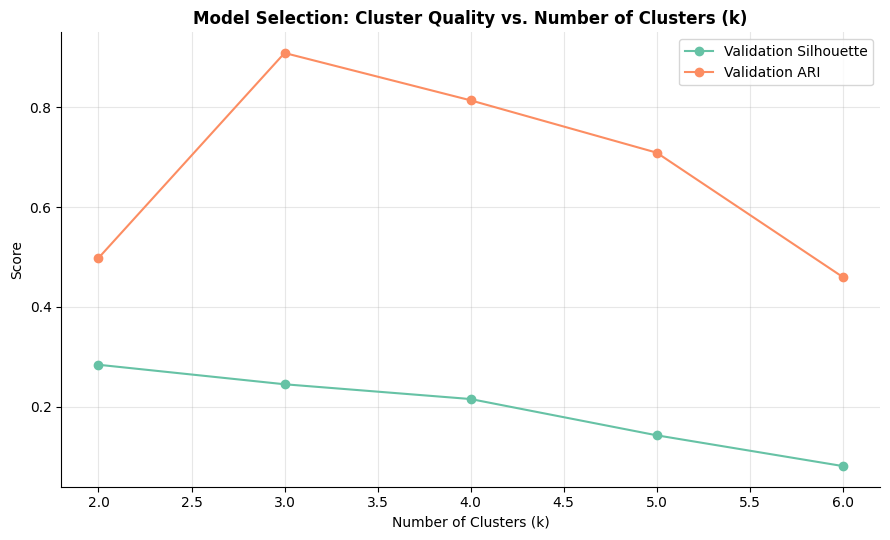

Best k by validation ARI: 3


In [17]:
plt.figure(figsize=(9, 5.5))
plt.plot(list(k_values), val_sil_list, marker="o", label="Validation Silhouette")
plt.plot(list(k_values), val_ari_list, marker="o", label="Validation ARI")
plt.title("Model Selection: Cluster Quality vs. Number of Clusters (k)", fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

best_k = list(k_values)[int(np.argmax(val_ari_list))]
print(f"Best k by validation ARI: {best_k}")


### Choosing the Best `k`

This plot compares the **validation Silhouette Score** and **validation ARI** for different values of `k`.

The best value is:

**`k = 3`**

Why?

- **`k=2`** combines some different wine groups together.
- **`k=3`** gives the highest ARI and the best overall result.
- **`k=4, 5, 6`** start splitting the natural groups into smaller pieces, so performance decreases.

This confirms that **3 clusters provide the best representation of the wine data**.

We will therefore keep **`k=3`** and next focus on choosing the best way to build the similarity graph.

## 10. Validation — Tune Before Touching Test Set



In [18]:
# With k fixed, sweep the similarity-graph hyperparameter: number of neighbors used
# to build the k-NN affinity graph. Too few neighbors -> a fragile, disconnected graph.
# Too many -> the graph becomes too dense and starts to blur across true cluster boundaries.
n_neighbors_values = [3, 5, 8, 10, 15, 20, 30]
val_ari_by_neighbors, val_sil_by_neighbors = [], []

for n_neighbors in n_neighbors_values:
    spectral = SpectralClustering(
        n_clusters=best_k,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors,
        assign_labels="kmeans",
        random_state=RANDOM_STATE,
    )
    train_cluster_labels = spectral.fit_predict(X_train_scaled)

    oos_extender = KNeighborsClassifier(n_neighbors=5)
    oos_extender.fit(X_train_scaled, train_cluster_labels)
    val_cluster_labels = oos_extender.predict(X_val_scaled)

    val_ari = adjusted_rand_score(y_val_true, val_cluster_labels)
    val_sil = silhouette_score(X_val_scaled, val_cluster_labels) if len(set(val_cluster_labels)) > 1 else -1

    val_ari_by_neighbors.append(val_ari)
    val_sil_by_neighbors.append(val_sil)

    print(f"n_neighbors={n_neighbors:>2} | Val Sil: {val_sil:.3f} | Val ARI: {val_ari:.3f}")

best_n_neighbors = n_neighbors_values[int(np.argmax(val_ari_by_neighbors))]
print(f"\nBest n_neighbors by validation ARI: {best_n_neighbors}")


n_neighbors= 3 | Val Sil: 0.284 | Val ARI: 0.498
n_neighbors= 5 | Val Sil: 0.245 | Val ARI: 0.909
n_neighbors= 8 | Val Sil: 0.245 | Val ARI: 0.909
n_neighbors=10 | Val Sil: 0.245 | Val ARI: 0.909
n_neighbors=15 | Val Sil: 0.245 | Val ARI: 0.909
n_neighbors=20 | Val Sil: 0.245 | Val ARI: 0.909
n_neighbors=30 | Val Sil: 0.245 | Val ARI: 0.909

Best n_neighbors by validation ARI: 5


### Choosing the Number of Neighbors

After choosing **`k = 3`**, we now choose how many nearby points should be connected in the similarity graph.

We test different values of `n_neighbors`:

- Too few neighbors → the graph may be too disconnected.
- Too many neighbors → the graph may connect points from different clusters.

We use the **validation ARI** to choose the best value.

The results show:

- `n_neighbors = 3` → ARI = **0.498**
- `n_neighbors ≥ 5` → ARI = **0.909**

The best value is therefore:

**`n_neighbors = 5`**

### Main Idea

Choosing the right `k` is not enough. We also need to build a good similarity graph.

Here, **5 neighbors gives the best validation result**, so we use:

**`k = 3` and `n_neighbors = 5`** for the final Spectral Clustering model.

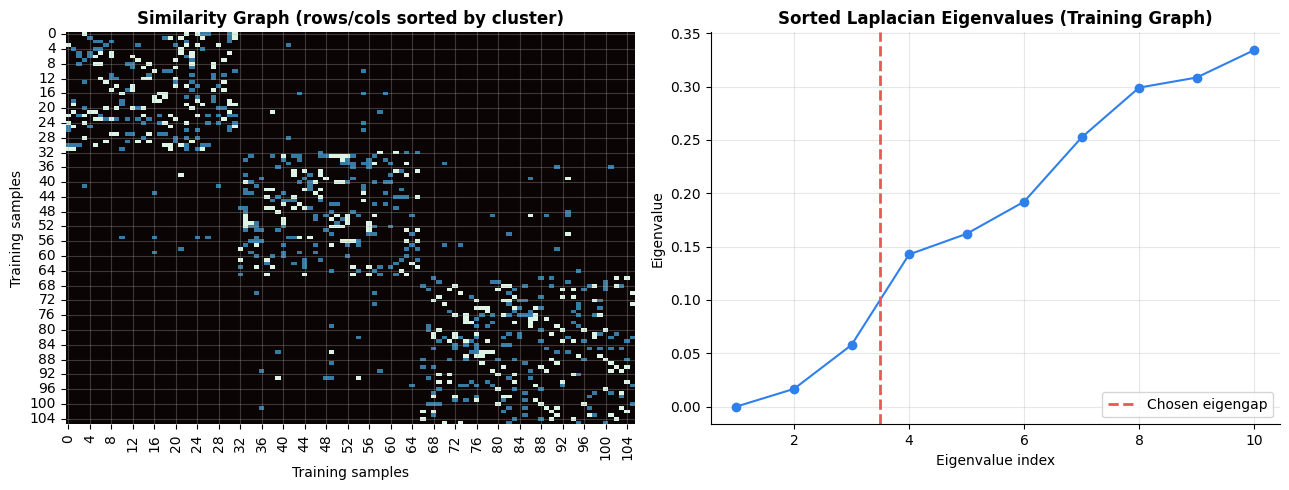

In [19]:
# Visualize the affinity graph and Laplacian eigengap on the TRAINING data
# using the final chosen hyperparameters, as a sanity check before touching the test set.
final_knn_graph = kneighbors_graph(
    X_train_scaled, n_neighbors=best_n_neighbors, mode="connectivity", include_self=False
)
final_knn_graph = 0.5 * (final_knn_graph + final_knn_graph.T)
final_L_norm = csgraph_laplacian(final_knn_graph, normed=True)
final_eigenvalues = np.linalg.eigvalsh(final_L_norm.toarray())
final_eigenvalues.sort()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Affinity matrix heatmap (rows/cols sorted by discovered cluster for a readable block structure)
spectral_final_preview = SpectralClustering(
    n_clusters=best_k, affinity="nearest_neighbors", n_neighbors=best_n_neighbors,
    assign_labels="kmeans", random_state=RANDOM_STATE,
)
preview_labels = spectral_final_preview.fit_predict(X_train_scaled)
sort_idx = np.argsort(preview_labels)
affinity_dense = final_knn_graph.toarray()[sort_idx][:, sort_idx]

sns.heatmap(affinity_dense, cmap="mako", cbar=False, ax=axes[0])
axes[0].set_title("Similarity Graph (rows/cols sorted by cluster)", fontweight="bold")
axes[0].set_xlabel("Training samples")
axes[0].set_ylabel("Training samples")

axes[1].plot(range(1, 11), final_eigenvalues[:10], marker="o", color="#2f80ed")
axes[1].axvline(best_k + 0.5, color="#eb5757", linestyle="--", linewidth=2, label="Chosen eigengap")
axes[1].set_title("Sorted Laplacian Eigenvalues (Training Graph)", fontweight="bold")
axes[1].set_xlabel("Eigenvalue index")
axes[1].set_ylabel("Eigenvalue")
axes[1].legend()

plt.tight_layout()
plt.show()


### Checking the Final Similarity Graph

Before evaluating the model on the test set, we check whether our chosen settings **`k = 3`** and **`n_neighbors = 5`** produce a sensible graph.

The plot shows two things:

- **Left — Similarity Graph:** The bright blocks along the diagonal represent groups of points that are strongly connected to each other. Very few connections between the blocks means the clusters are well separated.
- **Right — Eigenvalues:** There is a clear jump after the **3rd eigenvalue**, supporting our choice of **3 clusters**.

### Main Idea

Both plots tell us the same story:

**The graph contains 3 clear groups with strong connections inside each group and weak connections between groups.**

This gives us confidence that our chosen parameters are capturing real structure in the training data before we move to the final test evaluation.

## 11. Final Test Set Evaluation

We have now fixed all our model choices using only the **training and validation data**:

- `k = 3`
- `n_neighbors = 5`

We can now evaluate the final model on the **test set**, which has not been used before.

Because Spectral Clustering cannot directly predict new points, we use **K-NN as an out-of-sample extension** to assign the unseen test wines to the clusters discovered from the training data.

We then use three metrics:

- **Silhouette Score:** Measures how well separated the clusters are.
- **ARI:** Measures how closely the clusters match the real wine cultivars.
- **NMI:** Also measures the agreement between the discovered clusters and the real cultivars.

The real cultivar labels are used **only for this final evaluation**, not for training or choosing the model.

In [20]:
# Fit the final model only on training data using the selected validation parameters.
final_spectral = SpectralClustering(
    n_clusters=best_k,
    affinity="nearest_neighbors",
    n_neighbors=best_n_neighbors,
    assign_labels="kmeans",
    random_state=RANDOM_STATE,
)
final_train_labels = final_spectral.fit_predict(X_train_scaled)

# KNN is only an out-of-sample extension because Spectral Clustering has no native .predict().
final_oos_extender = KNeighborsClassifier(n_neighbors=5)
final_oos_extender.fit(X_train_scaled, final_train_labels)
final_spectral_test_labels = final_oos_extender.predict(X_test_scaled)

final_spectral_test_silhouette = silhouette_score(X_test_scaled, final_spectral_test_labels)
final_spectral_test_ari = adjusted_rand_score(y_test_true, final_spectral_test_labels)
final_spectral_test_nmi = normalized_mutual_info_score(y_test_true, final_spectral_test_labels)

# K-Means has a native .predict(), so it can assign test samples directly.
baseline_test_labels = baseline_kmeans.predict(X_test_scaled)
baseline_test_silhouette = silhouette_score(X_test_scaled, baseline_test_labels)
baseline_test_ari = adjusted_rand_score(y_test_true, baseline_test_labels)
baseline_test_nmi = normalized_mutual_info_score(y_test_true, baseline_test_labels)

results = pd.DataFrame({
    "Method": ["Spectral Clustering", "K-Means baseline"],
    "Silhouette": [final_spectral_test_silhouette, baseline_test_silhouette],
    "ARI": [final_spectral_test_ari, baseline_test_ari],
    "NMI": [final_spectral_test_nmi, baseline_test_nmi],
}).set_index("Method")

print(f"Selected parameters: k={best_k}, n_neighbors={best_n_neighbors}")
print("\nFinal test-set results:")
print(results.round(3))


Selected parameters: k=3, n_neighbors=5

Final test-set results:
                     Silhouette    ARI    NMI
Method                                       
Spectral Clustering       0.280  1.000  1.000
K-Means baseline          0.272  0.909  0.909


### What Do These Results Mean?

- **Silhouette:** Spectral Clustering has a slightly higher score (`0.280` vs. `0.272`), meaning its clusters are slightly better separated.
- **ARI:** Spectral Clustering gets **1.000**, meaning its clusters perfectly match the real wine cultivars.
- **NMI:** Spectral Clustering also gets **1.000**, confirming perfect agreement with the real cultivar groups.

Spectral Clustering performs **better than the K-Means baseline on the unseen test data**.

Most importantly, it successfully discovered the three real wine groups **without using the cultivar labels during training**.

This shows that the chemical features contain strong natural structure that Spectral Clustering was able to discover.

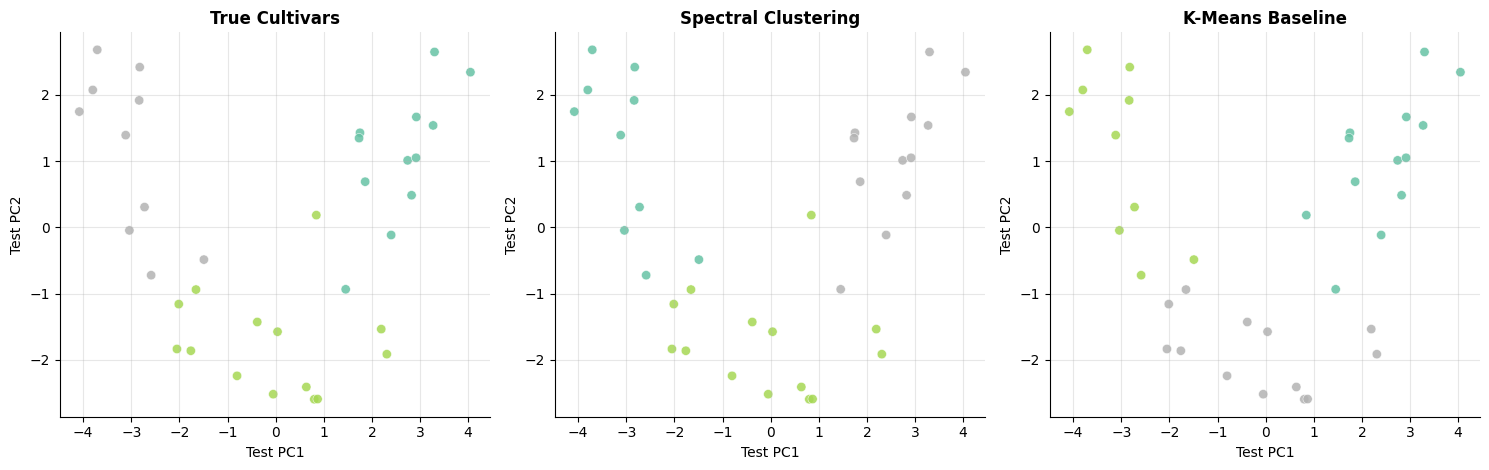

In [21]:
# Visualize held-out test wines in two PCA dimensions.
pca_test = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca_test.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
plot_data = [
    (y_test_true, "True Cultivars"),
    (final_spectral_test_labels, "Spectral Clustering"),
    (baseline_test_labels, "K-Means Baseline"),
]
for ax, (labels, title) in zip(axes, plot_data):
    ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=labels, cmap="Set2", s=45,
               alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Test PC1")
    ax.set_ylabel("Test PC2")
plt.tight_layout()
plt.show()


### Visualizing the Test Results

This plot shows the **unseen test wines** in 2D using PCA, just to make the results easier to visualize.

The three panels show:

- **True Cultivars:** The actual wine groups, used only as a reference.
- **Spectral Clustering:** The groups predicted by our final model.
- **K-Means:** The groups predicted by the baseline model.

If a model's plot looks similar to the **True Cultivars** plot, it means the model discovered groups that closely match the real wine varieties.

Here, the **Spectral Clustering plot closely matches the true cultivars**, which supports its perfect ARI and NMI scores.

> **Important:** PCA is used only for visualization. The models and evaluation metrics use all **13 standardized chemical features**.

## 12. Conclusion

In this notebook, we used the **Wine dataset** to see whether Spectral Clustering could discover natural groups of wines using only their **13 chemical features**.

We:

- Explored and prepared the data.
- Standardized the features correctly using the training data.
- Used PCA only to visualize the data.
- Compared **Spectral Clustering** with a **K-Means baseline**.
- Tested different values of `k` and `n_neighbors` using the validation set.
- Selected **`k = 3`** and **`n_neighbors = 5`**.
- Evaluated the final models on the **unseen test set**.

### Final Result

Spectral Clustering performed better than K-Means:

- **Spectral Clustering:** ARI = `1.000`, NMI = `1.000`
- **K-Means:** ARI = `0.909`, NMI = `0.909`

This means Spectral Clustering was able to **perfectly recover the three real wine groups** on the test data, without using the cultivar labels during training.

### Main Takeaway

Spectral Clustering is powerful because it can discover groups based on **connections and similarity between data points**, rather than only their distance from a center.

However, it is more computationally expensive and requires careful choices such as `k` and the graph parameters.

Most importantly, we selected the model using **training and validation data first**, and only then evaluated it on the untouched test set. This gives us a fair and reliable measure of performance on unseen wines.